In [1]:
import geopandas as gpd

buildings = gpd.read_file("../data/raw/osm/buildings.geojson")

# Project to metric CRS
buildings_proj = buildings.to_crs(epsg=32643)  # Delhi UTM Zone

# Building area in square meters
buildings_proj["building_area_m2"] = buildings_proj.area

print(buildings_proj["building_area_m2"].describe())

count     25596.000000
mean        458.540263
std        1377.270981
min           0.000000
25%         131.058754
50%         233.408013
75%         450.519459
max      100824.692126
Name: building_area_m2, dtype: float64


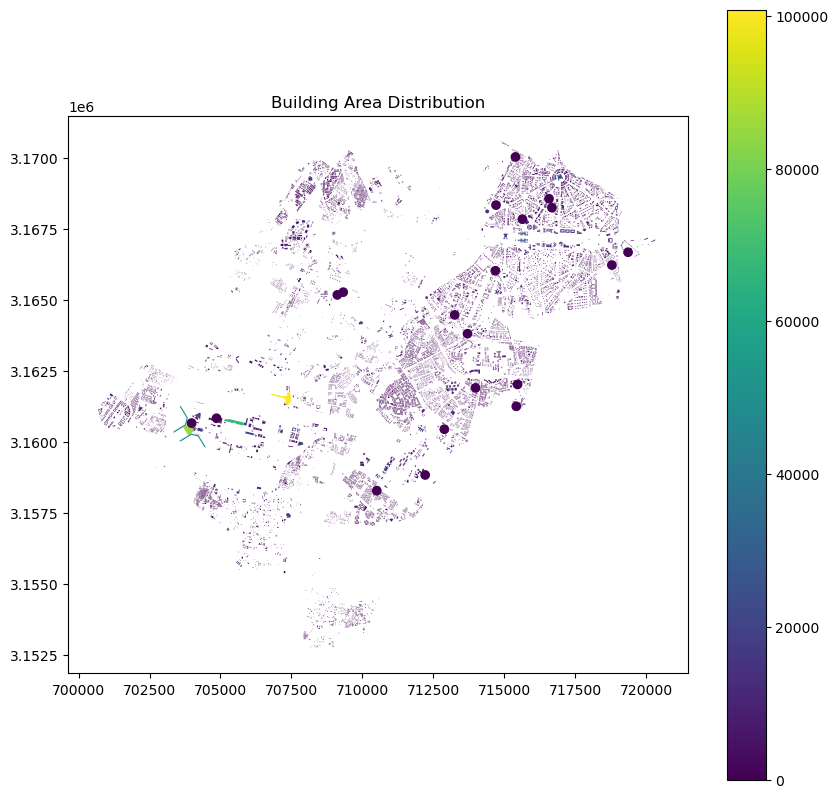

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

buildings_proj.plot(
    column="building_area_m2",
    ax=ax,
    legend=True
)

plt.title("Building Area Distribution")
plt.show()

In [4]:
import geopandas as gpd

roads = gpd.read_file("../data/raw/osm/roads.geojson")

print("Number of Roads:", len(roads))
print(roads.geometry.geom_type.value_counts())

Number of Roads: 20722
LineString    18888
Point          1813
Polygon          21
Name: count, dtype: int64


In [5]:
import geopandas as gpd

buildings = gpd.read_file("../data/raw/osm/buildings.geojson")
roads = gpd.read_file("../data/raw/osm/roads.geojson")

print("Buildings:", len(buildings))
print("Roads:", len(roads))

Buildings: 25596
Roads: 20722


In [6]:
import rasterio
import numpy as np

with rasterio.open("../data/raw/ndvi/Delhi_NDVI_2024.tif") as src:
    ndvi = src.read(1)

with rasterio.open("../data/raw/lst/Delhi_LST_2024.tif") as src:
    lst = src.read(1)

print(ndvi.shape)
print(lst.shape)

(5629, 5084)
(1877, 1695)


In [7]:
print("NDVI:", ndvi.shape)
print("LST:", lst.shape)

NDVI: (5629, 5084)
LST: (1877, 1695)


In [8]:
import rasterio
from rasterio.enums import Resampling

with rasterio.open("../data/raw/ndvi/Delhi_NDVI_2024.tif") as ndvi_src:
    ndvi = ndvi_src.read(1)
    target_shape = ndvi.shape

with rasterio.open("../data/raw/lst/Delhi_LST_2024.tif") as lst_src:
    lst_resampled = lst_src.read(
        1,
        out_shape=target_shape,
        resampling=Resampling.bilinear
    )

print("NDVI Shape:", ndvi.shape)
print("Resampled LST Shape:", lst_resampled.shape)

NDVI Shape: (5629, 5084)
Resampled LST Shape: (5629, 5084)


In [9]:
import numpy as np

ndvi_norm = (ndvi - np.nanmin(ndvi)) / (
    np.nanmax(ndvi) - np.nanmin(ndvi)
)

lst_norm = (lst_resampled - np.nanmin(lst_resampled)) / (
    np.nanmax(lst_resampled) - np.nanmin(lst_resampled)
)

print("NDVI normalized")
print("LST normalized")

NDVI normalized
LST normalized


In [10]:
heat_risk = (
    0.6 * lst_norm +
    0.4 * (1 - ndvi_norm)
)

print("Heat Risk Shape:", heat_risk.shape)

Heat Risk Shape: (5629, 5084)


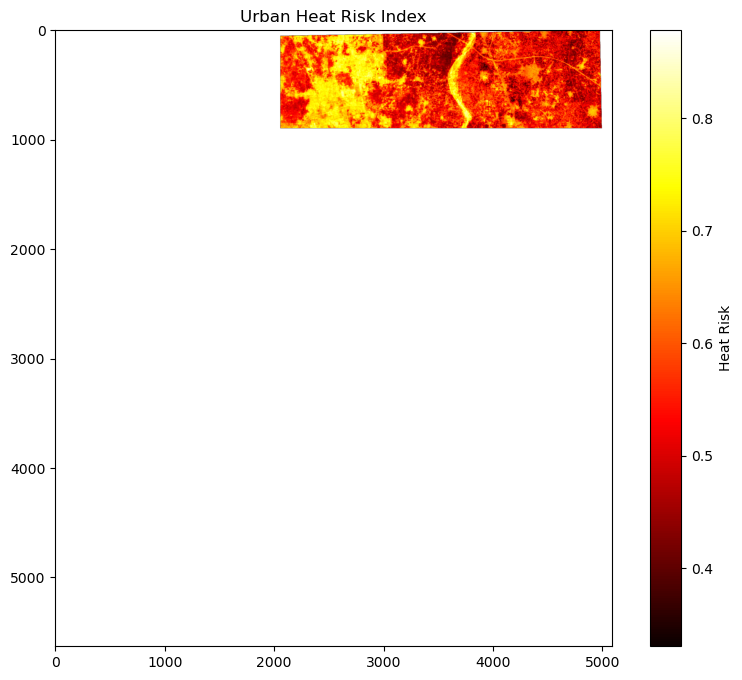

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(heat_risk, cmap="hot")

plt.colorbar(label="Heat Risk")

plt.title("Urban Heat Risk Index")

plt.show()

In [12]:
print("Min:", np.nanmin(heat_risk))
print("Max:", np.nanmax(heat_risk))
print("Mean:", np.nanmean(heat_risk))

Min: 0.3304932662677297
Max: 0.8783369904367944
Mean: 0.5821119744907957


In [13]:
with rasterio.open("../data/raw/ndvi/Delhi_NDVI_2024.tif") as src:
    profile = src.profile

profile.update(dtype=rasterio.float32, count=1)

with rasterio.open(
    "../data/processed/heat_risk.tif",
    "w",
    **profile
) as dst:
    dst.write(heat_risk.astype("float32"), 1)

print("Saved!")

Saved!


In [14]:
risk_class = np.where(
    heat_risk > 0.75, 3,
    np.where(heat_risk > 0.55, 2, 1)
)

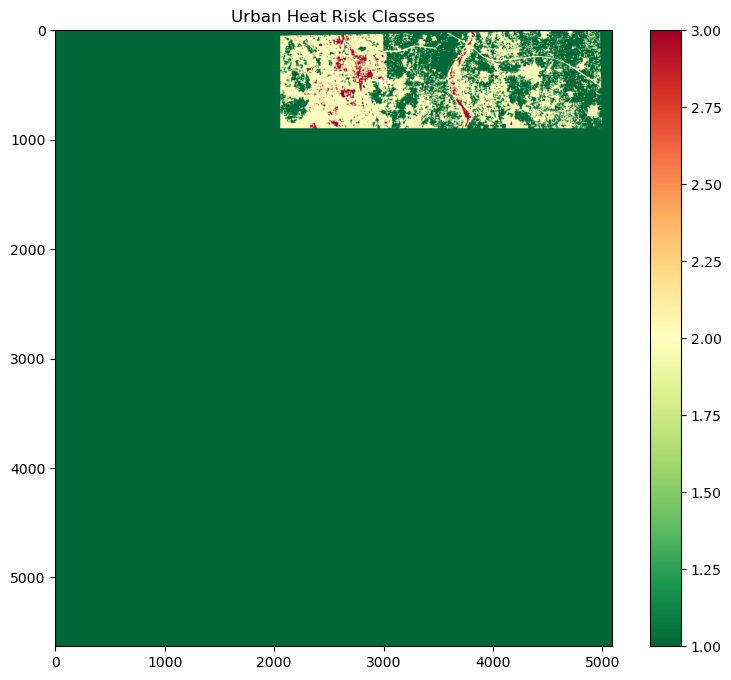

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(risk_class, cmap="RdYlGn_r")
plt.colorbar()
plt.title("Urban Heat Risk Classes")
plt.show()

In [16]:
import rasterio

with rasterio.open("../data/raw/ndvi/Delhi_NDVI_2024.tif") as ndvi_src:
    print("NDVI")
    print("Shape:", ndvi_src.shape)
    print("Bounds:", ndvi_src.bounds)
    print("CRS:", ndvi_src.crs)

with rasterio.open("../data/raw/lst/Delhi_LST_2024.tif") as lst_src:
    print("\nLST")
    print("Shape:", lst_src.shape)
    print("Bounds:", lst_src.bounds)
    print("CRS:", lst_src.crs)

NDVI
Shape: (5629, 5084)
Bounds: BoundingBox(left=679400.0, bottom=3142890.0, right=730240.0, top=3199180.0)
CRS: EPSG:32643

LST
Shape: (1877, 1695)
Bounds: BoundingBox(left=679395.0, bottom=3142875.0, right=730245.0, top=3199185.0)
CRS: EPSG:32643


In [17]:
print("NDVI NaNs:", np.isnan(ndvi).sum())
print("LST NaNs:", np.isnan(lst_resampled).sum())

print("NDVI Shape:", ndvi.shape)
print("LST Shape:", lst_resampled.shape)

NDVI NaNs: 26063163
LST NaNs: 3769928
NDVI Shape: (5629, 5084)
LST Shape: (5629, 5084)


In [18]:
print("Heat Risk Min:", np.nanmin(heat_risk))
print("Heat Risk Max:", np.nanmax(heat_risk))
print("Heat Risk Mean:", np.nanmean(heat_risk))

Heat Risk Min: 0.3304932662677297
Heat Risk Max: 0.8783369904367944
Heat Risk Mean: 0.5821119744907957


In [19]:
import numpy as np

ndvi_clean = np.nan_to_num(
    ndvi_norm,
    nan=np.nanmean(ndvi_norm)
)

lst_clean = np.nan_to_num(
    lst_norm,
    nan=np.nanmean(lst_norm)
)

In [20]:
heat_risk = (
    0.6 * lst_clean +
    0.4 * (1 - ndvi_clean)
)

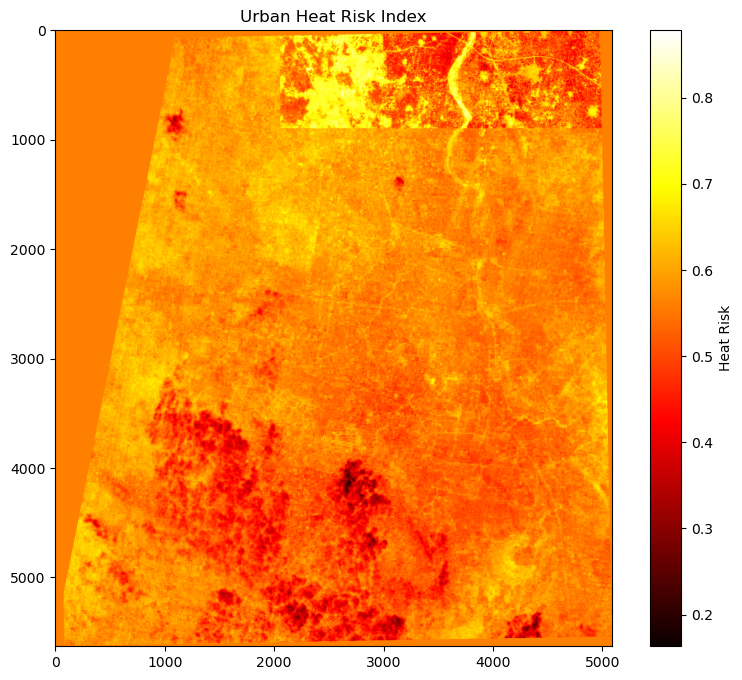

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(heat_risk, cmap="hot")

plt.colorbar(label="Heat Risk")

plt.title("Urban Heat Risk Index")

plt.show()

In [22]:
risk_class = np.where(
    heat_risk > 0.75, 3,
    np.where(heat_risk > 0.55, 2, 1)
)

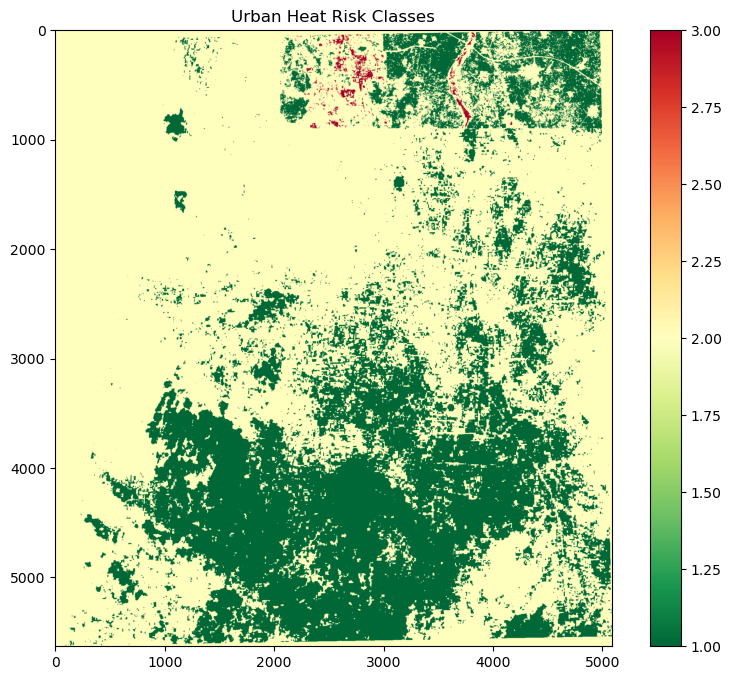

In [23]:
plt.figure(figsize=(10,8))

plt.imshow(risk_class, cmap="RdYlGn_r")

plt.colorbar()

plt.title("Urban Heat Risk Classes")

plt.show()

In [24]:
unique, counts = np.unique(risk_class, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 1: 8982906
Class 2: 19548438
Class 3: 86492


In [25]:
with rasterio.open("../data/raw/ndvi/Delhi_NDVI_2024.tif") as src:
    profile = src.profile

profile.update(dtype=rasterio.uint8, count=1)

with rasterio.open(
    "../data/processed/heat_risk_class.tif",
    "w",
    **profile
) as dst:
    dst.write(risk_class.astype("uint8"), 1)

print("Heat risk class raster saved!")

Heat risk class raster saved!


In [26]:
unique, counts = np.unique(risk_class, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 1: 8982906
Class 2: 19548438
Class 3: 86492


In [27]:
total = counts.sum()

for u, c in zip(unique, counts):
    print(f"Class {u}: {100*c/total:.2f}%")

Class 1: 31.39%
Class 2: 68.31%
Class 3: 0.30%
